In [1]:
# ==== Notebook cell: Pyrender vs PyTorch3D side-by-side debug ====
import os

os.environ.setdefault("PYOPENGL_PLATFORM", "egl")  # 需要 EGL 时启用

import sys
from typing import List, Optional, Tuple

import numpy as np
import torch
import trimesh
from IPython.display import HTML, display
from PIL import Image, ImageOps

sys.path.append("..")

import src.utils.render_utils as ru
from src.utils.render_utils_p3d import (
    export_renderings,
    make_grid_for_images_or_videos,
    render_normal_single_view,
    render_normal_views_around_mesh,
    render_single_view,
    render_views_around_mesh,
    trimesh_to_pytorch3d,
)

GLB_PATH = "/home/quanta/Downloads/failed_glb/0b8c873633504663a02572aa12c096ae.glb"
mesh = trimesh.load(GLB_PATH, force="scene")
mesh_p3d = trimesh_to_pytorch3d(mesh)
AZI, ELE, RADIUS = 30.0, 15.0, 3.5
H, W = 512, 512  # 注意：P3D 用 (H,W)
FOV = 40.0
LIGHT = 5.0  # 设为 None 就是“无光”
ZNEAR, ZFAR = 0.1, 10.0
NORMALIZE_DEPTH = True

/home/quanta/.conda/envs/partcrafter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: too many values to unpack (expected 2)

In [ ]:
img_pr, dep_pr = ru.render_single_view(
    mesh,
    azimuth=AZI,
    elevation=ELE,
    radius=RADIUS,
    image_size=(W, H),
    fov=FOV,
    light_intensity=LIGHT,
    znear=ZNEAR,
    zfar=ZFAR,
    normalize_depth=NORMALIZE_DEPTH,
    return_depth=True,
    return_type="pil",
)

# PyTorch3D 输出（其 image_size 语义是 (H,W)）
img_p3d, dep_p3d = render_single_view(
    mesh_p3d,
    azimuth=AZI,
    elevation=ELE,
    radius=RADIUS,
    image_size=(H, W),
    fov=FOV,
    light_intensity=LIGHT,
    znear=ZNEAR,
    zfar=ZFAR,
    normalize_depth=NORMALIZE_DEPTH,
    return_depth=True,
    return_type="pil",
)

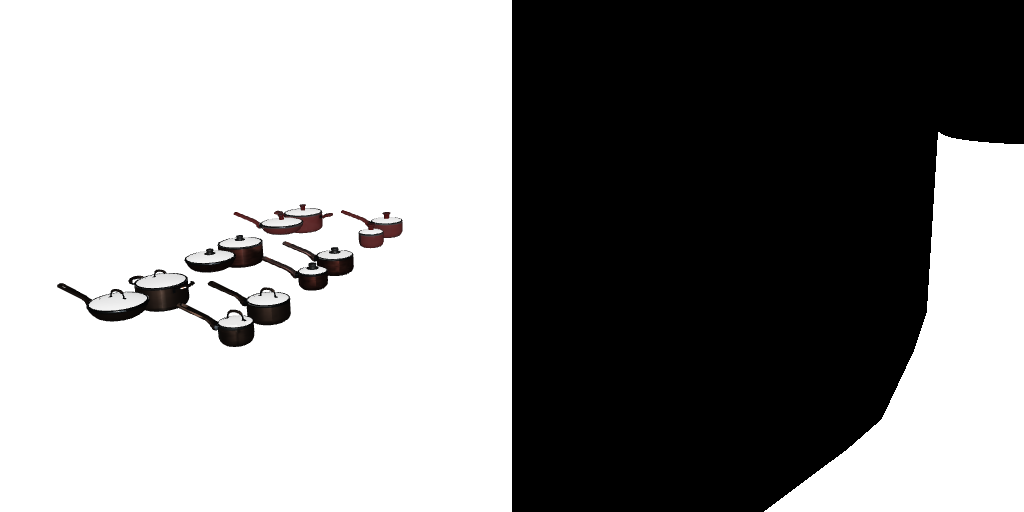

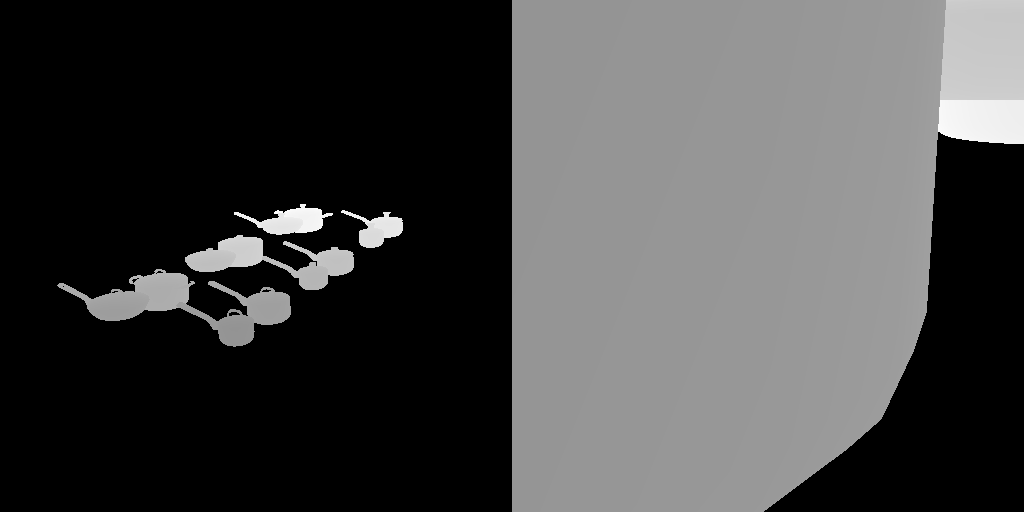

In [ ]:
# 拼接显示：颜色
grid_color = Image.new("RGB", (W*2, H))
grid_color.paste(img_pr.convert("RGB"), (0, 0))
grid_color.paste(img_p3d.convert("RGB"), (W, 0))
display(grid_color)

# 拼接显示：深度
grid_depth = Image.new("L", (W*2, H))
grid_depth.paste(dep_pr.convert("L"), (0, 0))
grid_depth.paste(dep_p3d.convert("L"), (W, 0))
display(grid_depth)

In [ ]:
mesh_p3d = trimesh_to_pytorch3d(mesh)